### FEATURE ENGINEERING ###

## 0. Import & Setup

In [1]:
# ── SETUP ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── STYLE ───────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor" : "#F8F8F8",
    "axes.grid"      : True,
    "grid.color"     : "#DDDDDD",
    "grid.linewidth" : 0.6,
    "font.family"    : "DejaVu Sans",
    "font.size"      : 11,
})
TEAL  = "#1D9E75"
BLUE  = "#378ADD"
CORAL = "#D85A30"
AMBER = "#BA7517"
RED   = "#E24B4A"
GRAY  = "#888780"

## 1. Load data

In [3]:
# ── LOAD DATA ───────────────────────────────────────────────
df = pd.read_csv('../data/raw/vietnam_tourism_trends_monthly_2010_2023.csv')
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").asfreq("MS")
# Fill missing
if df.isnull().sum().sum() > 0:
    df = df.interpolate(method="linear", limit_direction="forward")
df.head()

,arrivals,search_trends
date,,
2010-01-01,416249,93
2010-02-01,446323,75
2010-03-01,473509,88
2010-04-01,432608,84
2010-05-01,350982,85


## 2. Log transform

Dùng log1p thống nhất    
log1p(x) = log(x+1): an toàn khi arrivals=0 (COVID)

In [4]:
# ── LOG TRANSFORM ───────────────────────────────────────────────
df["log_arrivals"]      = np.log1p(df["arrivals"])
df["log_search_trends"] = np.log1p(df["search_trends"])
 
print(f"  [✓] Log1p transform:")
print(f"      log_arrivals     : {df['log_arrivals'].min():.3f} – {df['log_arrivals'].max():.3f}")
print(f"      log_search_trends: {df['log_search_trends'].min():.3f} – {df['log_search_trends'].max():.3f}")

  [✓] Log1p transform:
      log_arrivals     : 0.000 – 14.506
      log_search_trends: 3.091 – 4.615


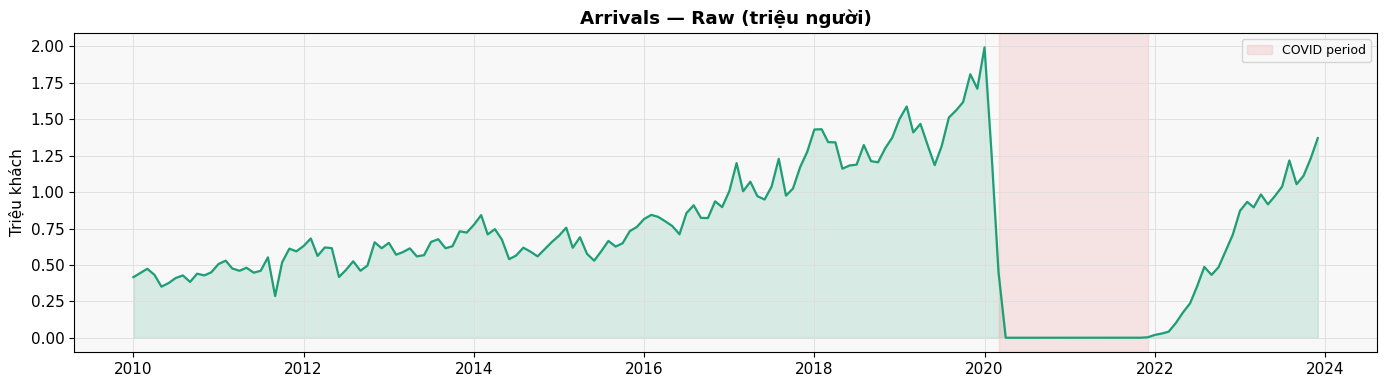

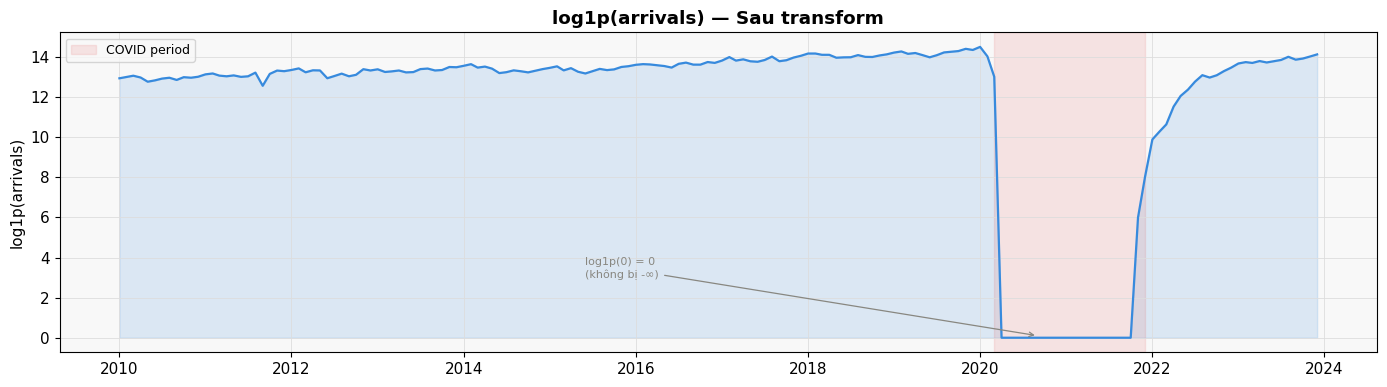

In [5]:
# ── PLOT: RAW vs LOG1p ────────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["arrivals"] / 1e6, color=TEAL, lw=1.6)
plt.fill_between(df.index, df["arrivals"] / 1e6, alpha=0.15, color=TEAL)
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.12, color=RED, label="COVID period")
plt.title("Arrivals — Raw (triệu người)", fontweight="bold")
plt.ylabel("Triệu khách")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step2_raw.png", dpi=150, bbox_inches="tight")
plt.show()
 
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["log_arrivals"], color=BLUE, lw=1.6)
plt.fill_between(df.index, df["log_arrivals"], alpha=0.15, color=BLUE)
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.12, color=RED, label="COVID period")
plt.annotate(
    "log1p(0) = 0\n(không bị -∞)",
    xy=(pd.Timestamp("2020-09-01"), 0.1),
    xytext=(pd.Timestamp("2015-06-01"), 3.0),
    arrowprops=dict(arrowstyle="->", color=GRAY, lw=0.9),
    fontsize=8, color=GRAY
)
plt.title("log1p(arrivals) — Sau transform", fontweight="bold")
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step2_log_transform.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# ── Time index (trend proxy cho ML) ───────────────────────────
df["time_idx"] = np.arange(len(df)) # giúp ML model hiểu xu hướng dài hạn

# ── First difference (stationarity support) ───────────────────
df["diff_1"] = df["log_arrivals"].diff().dropna()  # giúp SARIMA ổn định hơn, nhưng không dùng cho ML models

## 3. Covid dummy

3/2020–12/2021 = 1  (nhất quán với EDA: COVID shock = |z|>3)    
Mốc kết thúc 12/2021: VN mở cửa thí điểm từ 3/2022

In [7]:
# ── COVID DUMMY ───────────────────────────────────────────────
df["covid_dummy"] = (
    (df.index >= "2020-03-01") & (df.index <= "2021-12-01")
).astype(int)
 
n_covid = df["covid_dummy"].sum()
print(f"\n  [✓] COVID dummy: {n_covid} tháng = 1  (3/2020 – 12/2021)")


  [✓] COVID dummy: 22 tháng = 1  (3/2020 – 12/2021)


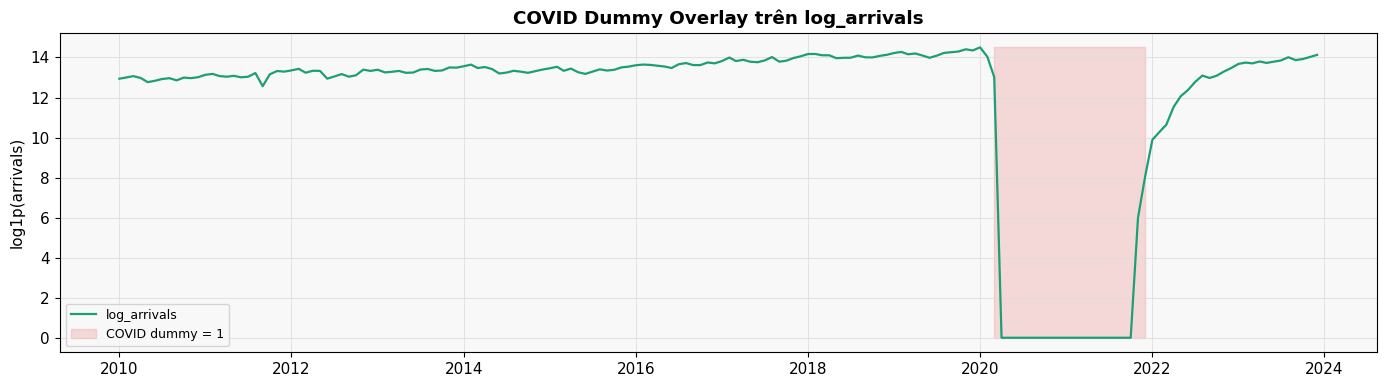

In [8]:
# ── Plot: COVID dummy overlay ─────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["log_arrivals"], color=TEAL, lw=1.6, label="log_arrivals")
plt.fill_between(
    df.index,
    df["log_arrivals"].min(), df["log_arrivals"].max(),
    where=(df["covid_dummy"] == 1),
    alpha=0.18, color=RED, label="COVID dummy = 1"
)
plt.title("COVID Dummy Overlay trên log_arrivals", fontweight="bold")
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step2_covid_dummy.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Lag features

In [9]:
# ── LAG FEATURES ───────────────────────────────────────────────
for lag in [1, 3, 6, 12, 24]:
    df[f"lag_{lag}"] = df["log_arrivals"].shift(lag)
 
print(f"\n  [✓] Lag features (dựa trên ACF/PACF spike lag 12, 24 từ EDA):")
for lag in [1, 3, 6, 12, 24]:
    print(f"      lag_{lag:2d}: {df[f'lag_{lag}'].isna().sum()} NaN đầu chuỗi")


  [✓] Lag features (dựa trên ACF/PACF spike lag 12, 24 từ EDA):
      lag_ 1: 1 NaN đầu chuỗi
      lag_ 3: 3 NaN đầu chuỗi
      lag_ 6: 6 NaN đầu chuỗi
      lag_12: 12 NaN đầu chuỗi
      lag_24: 24 NaN đầu chuỗi


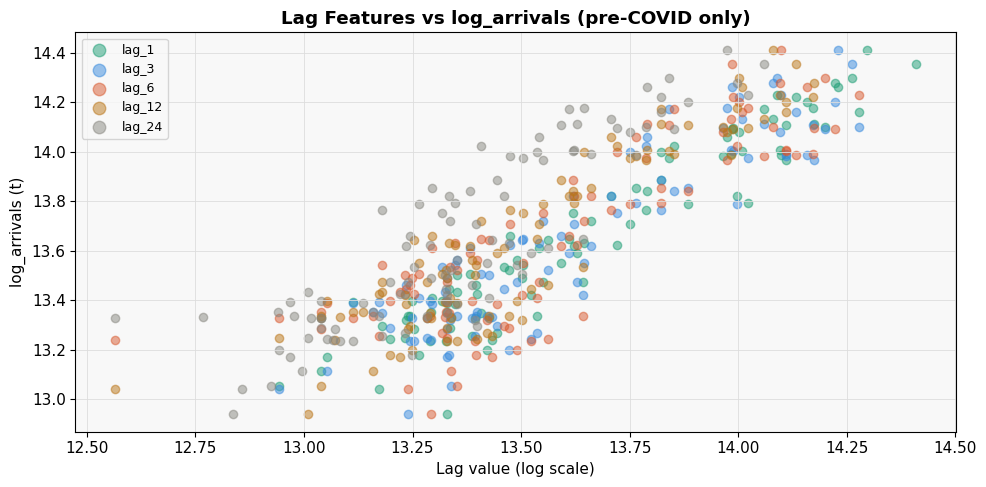

In [10]:
# ── Plot: Lag features scatter (pre-COVID) ────────────────────
df_pre = df[df.index < "2020-01-01"].dropna(subset=["lag_24"])
 
plt.figure(figsize=(10, 5))
for lag, col_c in zip([1, 3, 6, 12, 24], [TEAL, BLUE, CORAL, AMBER, GRAY]):
    plt.scatter(
        df_pre[f"lag_{lag}"],
        df_pre["log_arrivals"],
        alpha=0.5, color=col_c, label=f"lag_{lag}"
    )
plt.title("Lag Features vs log_arrivals (pre-COVID only)", fontweight="bold")
plt.xlabel("Lag value (log scale)")
plt.ylabel("log_arrivals (t)")
plt.legend(fontsize=9, markerscale=1.5)
plt.tight_layout()
plt.savefig("../outputs/step2_lag_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Rolling mean

shift(1) để tránh data leakage

In [11]:
# ── ROLLING MEAN FEATURES (SHIFT=1) ───────────────────────────────
for w in [3, 6, 12]:
    df[f"roll_mean_{w}"] = (
        df["log_arrivals"].rolling(window=w, min_periods=1).mean().shift(1)
    )
 
print(f"\n  [✓] Rolling mean (shift=1, tránh leakage): window 3, 6, 12")


  [✓] Rolling mean (shift=1, tránh leakage): window 3, 6, 12


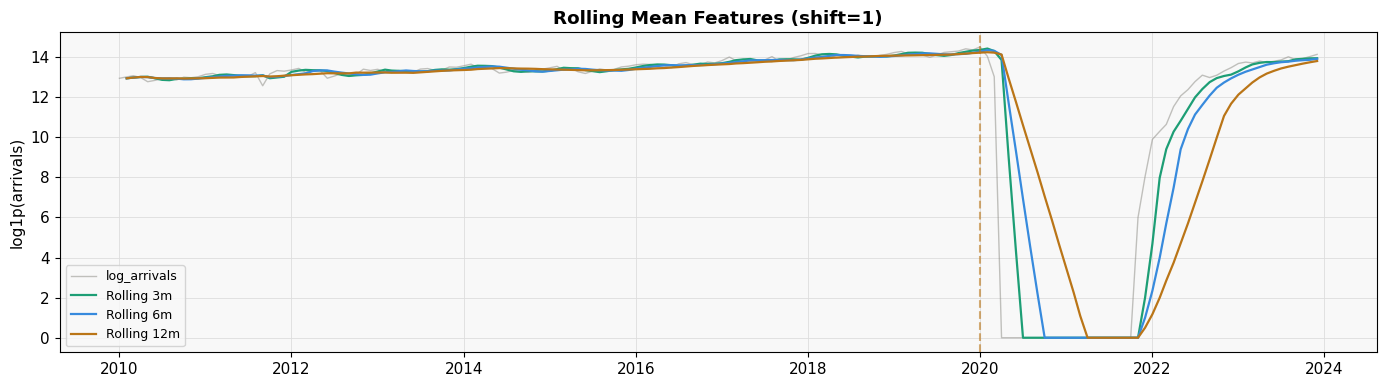

In [12]:
# ── Plot: Rolling mean ────────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["log_arrivals"], color=GRAY, lw=1.0, alpha=0.5, label="log_arrivals")
plt.plot(df.index, df["roll_mean_3"],  color=TEAL,  lw=1.6, label="Rolling 3m")
plt.plot(df.index, df["roll_mean_6"],  color=BLUE,  lw=1.6, label="Rolling 6m")
plt.plot(df.index, df["roll_mean_12"], color=AMBER, lw=1.6, label="Rolling 12m")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.6)
plt.title("Rolling Mean Features (shift=1)", fontweight="bold")
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step2_rolling_mean.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Seasonal dummies

drop_first=True: tháng 1 = base → tránh multicollinearity    
Dùng cho ML (Bước 7); SARIMA/ARIMAX tự xử lý seasonality

In [13]:
# ── SEASONAL DUMMIES ───────────────────────────────────────────────
month_dummies = pd.get_dummies(df.index.month, prefix="month", drop_first=True)  # dùng cho ML models (không dùng cho SARIMA)
month_dummies.index = df.index
df = pd.concat([df, month_dummies], axis=1)
 
dummy_cols = [c for c in df.columns if c.startswith("month_")]
print(f"\n  [✓] Month dummies: {len(dummy_cols)} biến (base = tháng 1)")


  [✓] Month dummies: 11 biến (base = tháng 1)


## 7. Train/Test Split

In [14]:
# ── TRAIN-TEST SPLIT ───────────────────────────────────────────────
train = df.loc[: "2019-12-01"].copy()
test  = df.loc["2020-01-01":].copy()

print(f"\n  ── TRAIN / TEST SPLIT ──────────────────────────────")
print(f"  Train: {train.index[0].strftime('%m/%Y')} → {train.index[-1].strftime('%m/%Y')}  ({len(train)} obs)")
print(f"  Test : {test.index[0].strftime('%m/%Y')}  → {test.index[-1].strftime('%m/%Y')}   ({len(test)} obs)")
print(f"  Tỉ lệ: {len(train)/(len(train)+len(test))*100:.0f}% / {len(test)/(len(train)+len(test))*100:.0f}%")
print(f"  COVID months trong test: {test['covid_dummy'].sum()} tháng → real stress test ✓")


  ── TRAIN / TEST SPLIT ──────────────────────────────
  Train: 01/2010 → 12/2019  (120 obs)
  Test : 01/2020  → 12/2023   (48 obs)
  Tỉ lệ: 71% / 29%
  COVID months trong test: 22 tháng → real stress test ✓


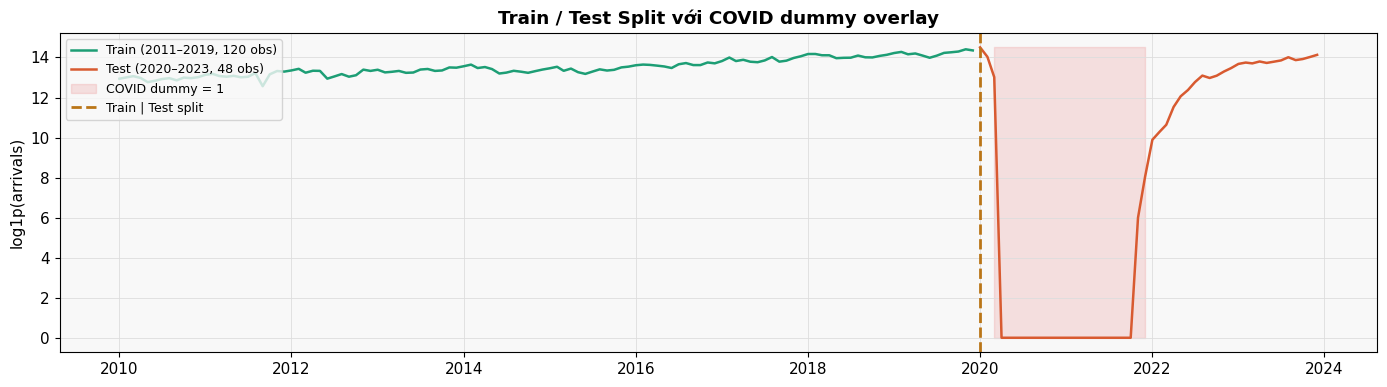

In [15]:
# ── Plot: Train/Test split ────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(train.index, train["log_arrivals"],
         color=TEAL, lw=1.8, label=f"Train (2011–2019, {len(train)} obs)")
plt.plot(test.index,  test["log_arrivals"],
         color=CORAL, lw=1.8, label=f"Test (2020–2023, {len(test)} obs)")
plt.fill_between(
    test.index,
    df["log_arrivals"].min(), df["log_arrivals"].max(),
    where=(test["covid_dummy"] == 1),
    alpha=0.15, color=RED, label="COVID dummy = 1"
)
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=2.0, ls="--",
            label="Train | Test split")
plt.title("Train / Test Split với COVID dummy overlay", fontweight="bold")
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/step2_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Tổng Hợp & Save

In [16]:
# ── FINAL CHECK & SAVE ───────────────────────────────────────────────
print(f"\n  Tổng số cột: {df.shape[1]}")
col_groups = {
    "🎯 Target"        : ["arrivals", "log_arrivals"],
    "📊 Exogenous"     : ["search_trends", "log_search_trends"],
    "🔴 Dummy"         : ["covid_dummy"],
    "⏪ Lag features"  : [f"lag_{l}" for l in [1, 3, 6, 12, 24]],
    "📈 Rolling mean"  : [f"roll_mean_{w}" for w in [3, 6, 12]],
    "📅 Month dummies" : dummy_cols,
}
print()
for group, cols in col_groups.items():
    print(f"  {group}: {', '.join(cols)}")
 
df.to_csv("../data/processed_data.csv")
print(f"\n  [✓] Processed data saved to '../data/processed_data.csv'")


  Tổng số cột: 26

  🎯 Target: arrivals, log_arrivals
  📊 Exogenous: search_trends, log_search_trends
  🔴 Dummy: covid_dummy
  ⏪ Lag features: lag_1, lag_3, lag_6, lag_12, lag_24
  📈 Rolling mean: roll_mean_3, roll_mean_6, roll_mean_12
  📅 Month dummies: month_2, month_3, month_4, month_5, month_6, month_7, month_8, month_9, month_10, month_11, month_12

  [✓] Processed data saved to '../data/processed_data.csv'


✓ log1p xuyên suốt — an toàn với COVID zeros   
✓ covid_dummy      — 22 tháng (3/2020–12/2021)   
✓ lag_1/3/6/12     — dựa trên ACF spike (EDA)   
✓ roll_mean_3/6/12 — shift=1, tránh data leakage   
✓ month dummies    — 11 biến, base = tháng 1   
✓ Train: 108 obs (2011–2019) | Test: 48 obs (2020–2023)   
✓ processed_data.csv  